In [5]:
# Import libraries
'''Main'''
import numpy as np
import pandas as pd
import os, time
import pickle, gzip

'''Data Viz'''
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
color = sns.color_palette()
%matplotlib inline

'''Data Prep and Model Evaluation'''
from sklearn import preprocessing as pp
from sklearn.model_selection import train_test_split 
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [7]:
# This safely joins paths regardless of OS
file_path = os.path.join(os.getcwd(), '..', 'Dataset', 'mnist.pkl.gz')

with gzip.open(file_path, 'rb') as f:
    train_set, validation_set, test_set = pickle.load(f, encoding='latin1')

X_train, y_train = train_set[0], train_set[1]
X_validation, y_validation = validation_set[0], validation_set[1]
X_test, y_test = test_set[0], test_set[1]

C:\Users\Beka\AppData\Local\Temp\ipykernel_4780\4249853014.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  train_set, validation_set, test_set = pickle.load(f, encoding='latin1')


In [8]:
# Create Pandas DataFrames from the datasets
train_index = range(0,len(X_train))
validation_index = range(len(X_train), \
                         len(X_train)+len(X_validation))
test_index = range(len(X_train)+len(X_validation), \
                   len(X_train)+len(X_validation)+len(X_test))

X_train = pd.DataFrame(data=X_train,index=train_index)
y_train = pd.Series(data=y_train,index=train_index)

X_validation = pd.DataFrame(data=X_validation,index=validation_index)
y_validation = pd.Series(data=y_validation,index=validation_index)

X_test = pd.DataFrame(data=X_test,index=test_index)
y_test = pd.Series(data=y_test,index=test_index)

In [9]:
# Principal Component Analysis (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=784, random_state=42, whiten=False)

X_train_pca = pca.fit_transform(X_train)
X_train_pca = pd.DataFrame(data=X_train_pca, index=train_index)

# K-Means

In [12]:
# KMeans - Inertia as the numver of clusters varies
from sklearn.cluster import KMeans

kMeans_inertia = pd.DataFrame(data = [], index = range(2, 21), columns=['Inertia'])

for n_clusters in range(2, 21):
    kmeans = KMeans(n_clusters=n_clusters, random_state= 2018, n_init=10, max_iter=300, tol=0.0001)
    cutoff = 99
    kmeans.fit(X_train_pca.iloc[:, 0:cutoff])
    kMeans_inertia.loc[n_clusters] = kmeans.inertia_

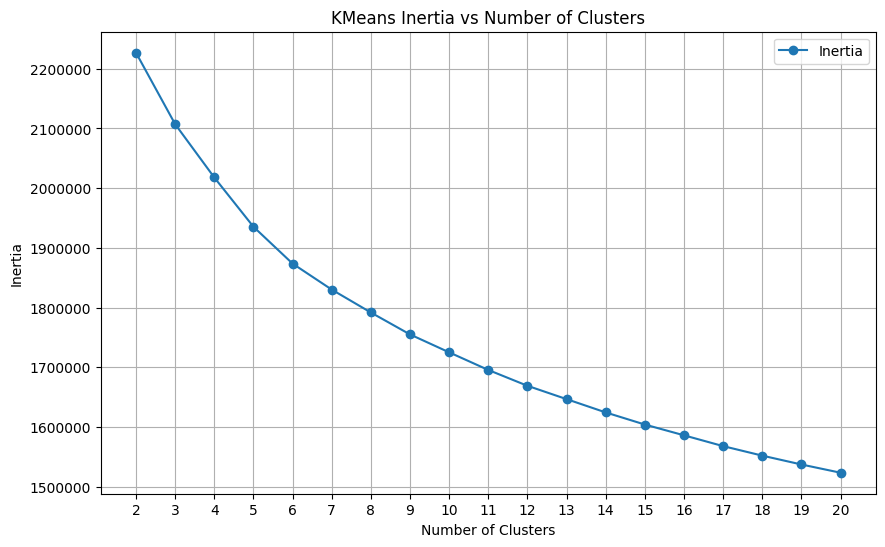

In [ ]:
import matplotlib.ticker as mtick  # Import for formatting

# Your original plot code
kMeans_inertia.plot(figsize=(10, 6), marker='o')
plt.title('KMeans Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(2, 21))

# --- TO FIX DIGITS ---
ax = plt.gca()  # Get current axis
# '%.0f' removes all decimals; '%.2f' would show two decimals
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f')) 
# -------------------------------------

plt.grid()
plt.show()


In [18]:
# Evaluating the clustering results
def analyzeCluster(clusterDF, labelsDF):
    countByCluster = \
        pd.DataFrame(data=clusterDF['cluster'].value_counts())
    countByCluster.reset_index(inplace=True,drop=False)
    countByCluster.columns = ['cluster','clusterCount']
        
    preds = pd.concat([labelsDF,clusterDF], axis=1)
    preds.columns = ['trueLabel','cluster']
    
    countByLabel = pd.DataFrame(data=preds.groupby('trueLabel').count())
        
    countMostFreq = \
        pd.DataFrame(data=preds.groupby('cluster').agg( \
                        lambda x:x.value_counts().iloc[0]))
    countMostFreq.reset_index(inplace=True,drop=False)
    countMostFreq.columns = ['cluster','countMostFrequent']
    
    accuracyDF = countMostFreq.merge(countByCluster, \
                        left_on="cluster",right_on="cluster")
    overallAccuracy = accuracyDF.countMostFrequent.sum()/ \
                        accuracyDF.clusterCount.sum()
    
    accuracyByLabel = accuracyDF.countMostFrequent/ \
                        accuracyDF.clusterCount
    
    return countByCluster, countByLabel, countMostFreq, \
            accuracyDF, overallAccuracy, accuracyByLabel

In [19]:
# KMeans accuracy
n_clusters = 5
n_init = 10
max_iter = 300
tol = 0.0001
random_state = 2018

kMeans_inertia = \
    pd.DataFrame(data=[],index=range(2,21),columns=['inertia'])
overallAccuracy_kMeansDF = \
    pd.DataFrame(data=[],index=range(2,21),columns=['overallAccuracy'])

for n_clusters in range(2,21):
    kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, \
                max_iter=max_iter, tol=tol, random_state=random_state)

    cutoff = 99
    kmeans.fit(X_train_pca.loc[:,0:cutoff])
    kMeans_inertia.loc[n_clusters] = kmeans.inertia_
    X_train_kmeansClustered = kmeans.predict(X_train_pca.loc[:,0:cutoff])
    X_train_kmeansClustered = \
        pd.DataFrame(data=X_train_kmeansClustered, index=X_train.index, \
                     columns=['cluster'])
    
    countByCluster_kMeans, countByLabel_kMeans, countMostFreq_kMeans, \
        accuracyDF_kMeans, overallAccuracy_kMeans, accuracyByLabel_kMeans \
        = analyzeCluster(X_train_kmeansClustered, y_train)
    
    overallAccuracy_kMeansDF.loc[n_clusters] = overallAccuracy_kMeans

<Axes: >

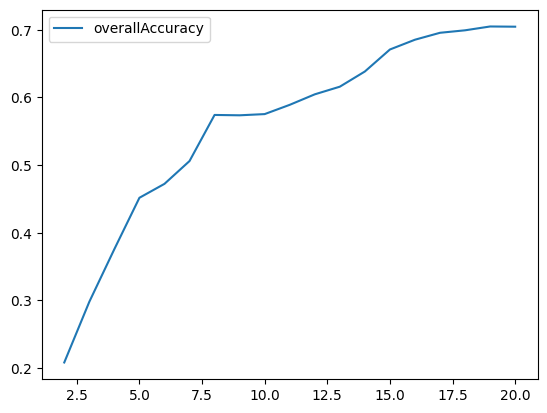

In [20]:
# Plot accuracy
overallAccuracy_kMeansDF.plot()

In [21]:
# Accuracy by cluster
accuracyByLabel_kMeans

0     0.707274
1     0.835307
2     0.410610
3     0.468279
4     0.950852
5     0.885130
6     0.498922
7     0.800000
8     0.951595
9     0.850885
10    0.568695
11    0.780126
12    0.454222
13    0.603049
14    0.492416
15    0.940727
16    0.905392
17    0.919469
18    0.931121
19    0.892488
dtype: float64

# Hierarchical Clustering